# EDA — ACLED weekly conflict panel, Ukraine

Exploratory analysis of the ACLED weekly aggregates built by
`src/data/build_acled_weekly.py`.

Raw ACLED export is already weekly but split by `admin1` × `sub_event_type`.
The builder collapses admin1 to country level and pivots `sub_event_type`
into features for `events`, `fatalities`, and `population_exposure`.

```bash
python -m src.data.build_acled_weekly
```

**Contents**
1. Load raw + weekly panels
2. Schema & coverage
3. Totals over time (events / fatalities / population exposure)
4. Sub-event-type composition
5. Top sub-event types: time series
6. Regime shift (pre / post Feb-2022)
7. Correlations & concentration
8. Takeaways


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils import load_config, repo_path
from src.data.build_acled_weekly import METRIC_COLS, build_acled_weekly, load_acled_raw

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
cfg["country"], cfg["data"]["acled_raw_path"]


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


({'name': 'Ukraine', 'gdelt_code': 'UP'},
 'data/raw/acled/ACLED Data_2026-09-08_event_date_from_1997-01-01_event_date_to_2026-09-08.csv')

## 1. Load data

Rebuild the weekly panels if they are missing, then load:
- `raw` — original ACLED export (admin1 × sub_event_type × week)
- `long` — country-level long panel (week × sub_event_type)
- `wide` — modeling-ready wide panel (one row per week)


In [2]:
raw_path = repo_path(cfg["data"]["acled_raw_path"])
long_path = repo_path(cfg["data"]["acled_weekly_long_path"])
wide_path = repo_path(cfg["data"]["acled_weekly_panel_path"])

if not long_path.exists() or not wide_path.exists():
    long, wide = build_acled_weekly(cfg)
else:
    long = pd.read_parquet(long_path)
    wide = pd.read_parquet(wide_path)

raw = load_acled_raw(raw_path)
for df in (long, wide):
    df["week"] = pd.to_datetime(df["week"])
    df["week_start"] = pd.to_datetime(df["week_start"])

print(f"raw:  {raw.shape[0]:,} rows, {raw['week'].nunique()} weeks, {raw['admin1'].nunique()} admin1")
print(f"long: {long.shape[0]:,} rows ({long['week'].nunique()} weeks × {long['sub_event_type'].nunique()} sub_event_types)")
print(f"wide: {wide.shape[0]} weeks × {wide.shape[1]} cols  ({wide['week'].min().date()} .. {wide['week'].max().date()})")
wide[["week", "week_label", "total_events", "total_fatalities", "total_population_exposure"]].tail(8)


raw:  19,723 rows, 453 weeks, 27 admin1
long: 4,547 rows (453 weeks × 25 sub_event_types)
wide: 453 weeks × 81 cols  (2017-12-30 .. 2026-08-29)


,week,week_label,total_events,total_fatalities,total_population_exposure
445,2026-07-11,2026-W28,2053,982,8080817
446,2026-07-18,2026-W29,2049,906,8916568
447,2026-07-25,2026-W30,2091,999,9949720
448,2026-08-01,2026-W31,2039,862,8693991
449,2026-08-08,2026-W32,1984,920,9045922
450,2026-08-15,2026-W33,1974,897,6949827
451,2026-08-22,2026-W34,1863,903,7159893
452,2026-08-29,2026-W35,1900,1112,0


## 2. Schema & coverage

Wide features are `{sanitized_sub_event_type}_{events|fatalities|population_exposure}`.
ACLED `week` is Saturday-based; `week_start` is the ISO Monday for joining GDELT.


In [3]:
feature_cols = [c for c in wide.columns if any(c.endswith(f"_{m}") for m in METRIC_COLS) and not c.startswith("total_")]
print(f"feature columns: {len(feature_cols)}  (= {long['sub_event_type'].nunique()} types × {len(METRIC_COLS)} metrics)")
print("\nsub_event_type ↔ key mapping:")
print(long.groupby(["sub_event_type", "sub_event_key", "event_type"], dropna=False)
        .size().reset_index(name="n_weeks")
        .sort_values("n_weeks", ascending=False)
        .to_string(index=False))

print("\nnulls in wide:", int(wide.isna().sum().sum()))
print("weeks with zero total_events:", int((wide["total_events"] == 0).sum()))


feature columns: 75  (= 25 types × 3 metrics)

sub_event_type ↔ key mapping:
                     sub_event_type                       sub_event_key                 event_type  n_weeks
                        Armed clash                         armed_clash                    Battles      453
  Shelling/artillery/missile attack   shelling_artillery_missile_attack Explosions/Remote violence      453
                   Peaceful protest                    peaceful_protest                   Protests      445
      Remote explosive/landmine/IED       remote_explosive_landmine_ied Explosions/Remote violence      403
              Disrupted weapons use               disrupted_weapons_use     Strategic developments      376
                             Attack                              attack Violence against civilians      319
       Looting/property destruction        looting_property_destruction     Strategic developments      310
                   Air/drone strike                    air_

## 3. Totals over time


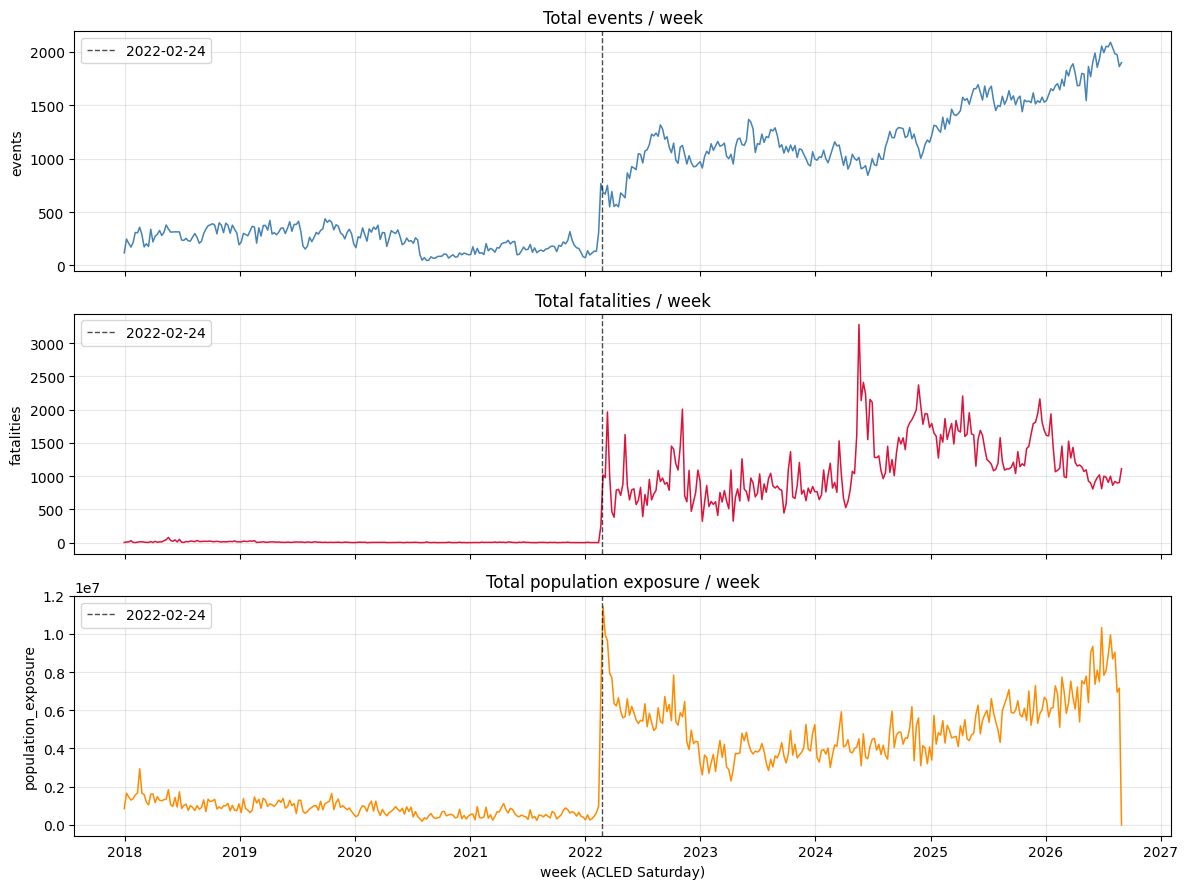

,total_events,total_fatalities,total_population_exposure
count,453.0,453.0,453.0
mean,775.1,603.9,3103440.6
std,571.8,665.3,2477302.9
min,47.0,0.0,0.0
25%,249.0,4.0,812964.0
50%,751.0,526.0,3030548.0
75%,1198.0,1084.0,5055605.0
max,2091.0,3281.0,11431542.0


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, color, title in zip(
    axes,
    ["total_events", "total_fatalities", "total_population_exposure"],
    ["steelblue", "crimson", "darkorange"],
    ["Total events / week", "Total fatalities / week", "Total population exposure / week"],
):
    ax.plot(wide["week"], wide[col], color=color, lw=1.1)
    ax.axvline(pd.Timestamp("2022-02-24"), color="black", ls="--", lw=1, alpha=0.7, label="2022-02-24")
    ax.set_ylabel(col.replace("total_", ""))
    ax.set_title(title)
    ax.legend(loc="upper left")

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("week (ACLED Saturday)")
fig.tight_layout()
plt.show()

wide[["total_events", "total_fatalities", "total_population_exposure"]].describe().round(1)


## 4. Sub-event-type composition

Share of all-time events / fatalities / population exposure by `sub_event_type`.


                                     events  fatalities  population_exposure  events_pct  fatalities_pct  population_exposure_pct
sub_event_type                                                                                                                   
Shelling/artillery/missile attack    131041       42860            525386841       37.32           15.67                    37.37
Armed clash                          105254      203324            188805994       29.98           74.32                    13.43
Air/drone strike                      88655       22486            533426507       25.25            8.22                    37.94
Disrupted weapons use                 10769          35                    0        3.07            0.01                     0.00
Peaceful protest                       6730           0             31464505        1.92            0.00                     2.24
Remote explosive/landmine/IED          2400        1269             66773227        0.68  

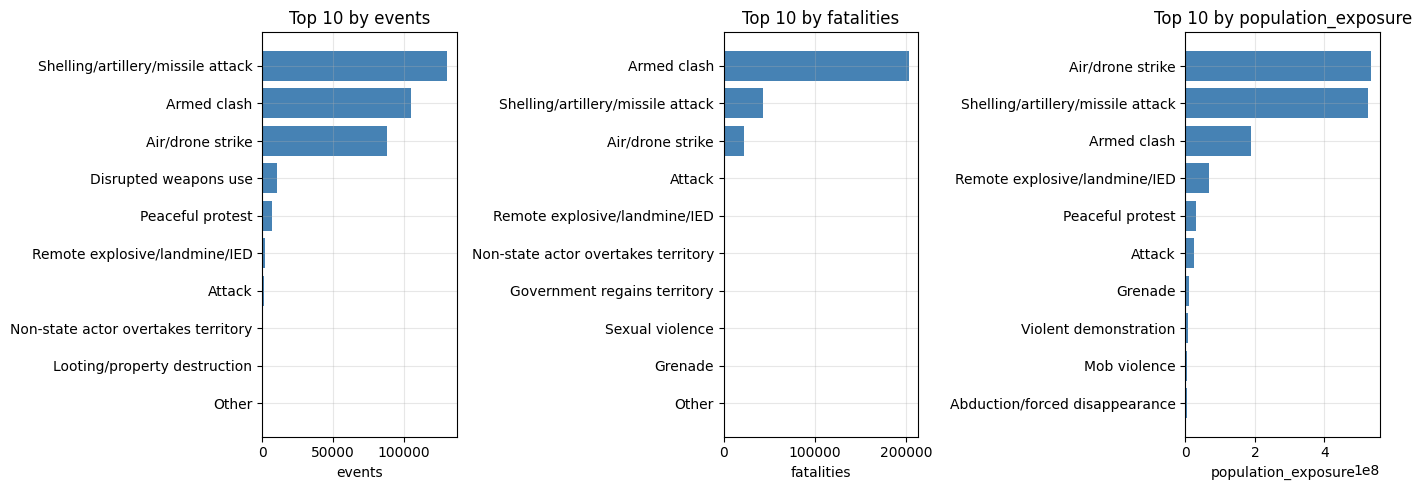

,events,fatalities,population_exposure,events_pct,fatalities_pct,population_exposure_pct
sub_event_type,,,,,,
Shelling/artillery/missile attack,131041,42860,525386841,37.32,15.67,37.37
Armed clash,105254,203324,188805994,29.98,74.32,13.43
Air/drone strike,88655,22486,533426507,25.25,8.22,37.94
Disrupted weapons use,10769,35,0,3.07,0.01,0.00
Peaceful protest,6730,0,31464505,1.92,0.00,2.24
Remote explosive/landmine/IED,2400,1269,66773227,0.68,0.46,4.75
Attack,1108,1749,25755564,0.32,0.64,1.83
Non-state actor overtakes territory,971,1083,2152332,0.28,0.40,0.15
Looting/property destruction,944,0,0,0.27,0.00,0.00


In [5]:
agg = (long.groupby("sub_event_type")[list(METRIC_COLS)].sum()
         .sort_values("events", ascending=False))
agg_pct = (agg / agg.sum() * 100).round(2)
agg_pct.columns = [f"{c}_pct" for c in agg_pct.columns]
comp = pd.concat([agg, agg_pct], axis=1)
print(comp.head(15).to_string())

top_n = 10
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, METRIC_COLS):
    s = agg[metric].sort_values(ascending=True).tail(top_n)
    ax.barh(s.index, s.values, color="steelblue")
    ax.set_title(f"Top {top_n} by {metric}")
    ax.set_xlabel(metric)
fig.tight_layout()
plt.show()
comp.head(15)


## 5. Top sub-event types: weekly time series

Stacked weekly events for the top sub-event types by total volume.


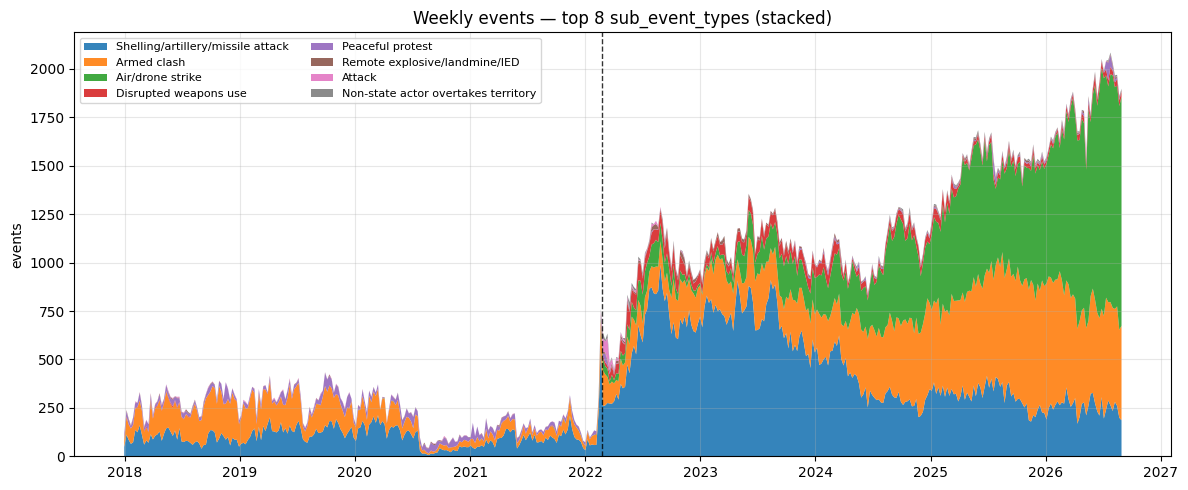

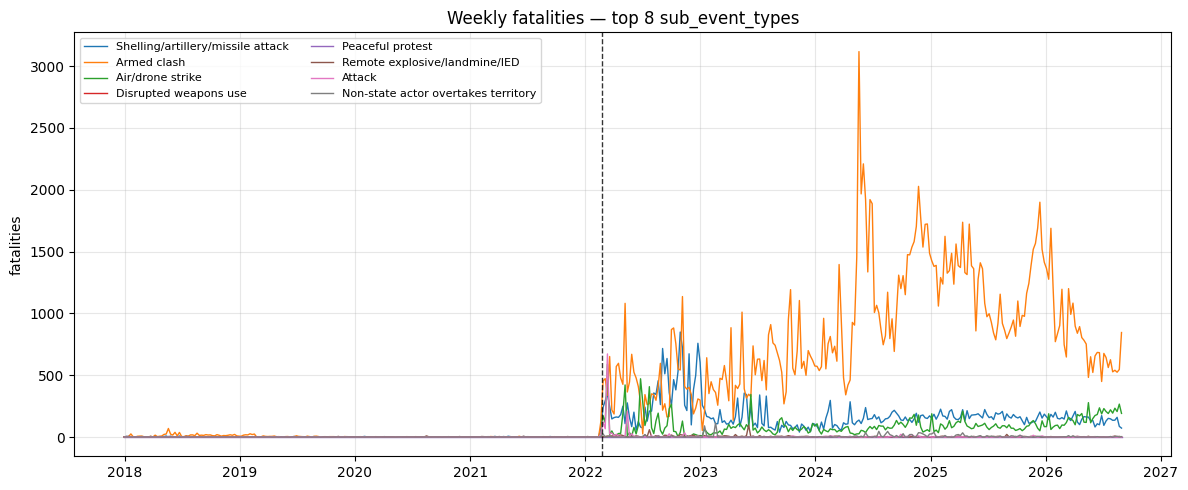

In [6]:
TOP_K = 8
top_types = agg.head(TOP_K).index.tolist()
ts = (long[long["sub_event_type"].isin(top_types)]
        .pivot_table(index="week", columns="sub_event_type", values="events", aggfunc="sum", fill_value=0)
        .reindex(columns=top_types))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(ts.index, [ts[c].values for c in ts.columns], labels=ts.columns, alpha=0.9)
ax.axvline(pd.Timestamp("2022-02-24"), color="black", ls="--", lw=1, alpha=0.8)
ax.set_title(f"Weekly events — top {TOP_K} sub_event_types (stacked)")
ax.set_ylabel("events")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

# fatalities for the same top types
ts_f = (long[long["sub_event_type"].isin(top_types)]
          .pivot_table(index="week", columns="sub_event_type", values="fatalities", aggfunc="sum", fill_value=0)
          .reindex(columns=top_types))
fig, ax = plt.subplots(figsize=(12, 5))
for c in ts_f.columns:
    ax.plot(ts_f.index, ts_f[c], lw=1, label=c)
ax.axvline(pd.Timestamp("2022-02-24"), color="black", ls="--", lw=1, alpha=0.8)
ax.set_title(f"Weekly fatalities — top {TOP_K} sub_event_types")
ax.set_ylabel("fatalities")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()


## 6. Regime comparison (pre / post 2022-02-24)

Mean weekly totals and composition before vs after the full-scale invasion.


                total_events                              total_fatalities                              total_population_exposure                                           
                       count    mean  median    std   max            count    mean  median    std   max                     count       mean     median        std       max
regime                                                                                                                                                                      
post_2022-02-24          236  1266.7  1183.0  334.7  2091              236  1151.4  1068.0  471.8  3281                       236  5160478.3  4948260.0  1623339.5  11431542
pre_2022-02-24           217   240.4   236.0  105.0   767              217     8.5     4.0   18.8   247                       217   866293.5   799438.0   569272.0   6942700

Largest composition shifts (post − pre, percentage points):
regime                                post   pre  delta_pp
sub_event_type 

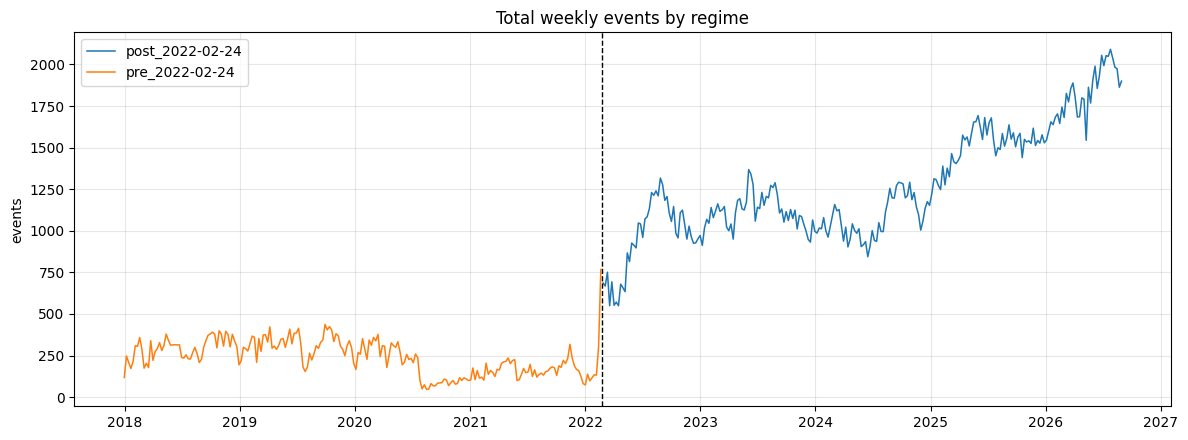

total_events                              total_fatalities  \
                       count    mean  median    std   max            count   
regime                                                                       
post_2022-02-24          236  1266.7  1183.0  334.7  2091              236   
pre_2022-02-24           217   240.4   236.0  105.0   767              217   

                                             total_population_exposure  \
                   mean  median    std   max                     count   
regime                                                                   
post_2022-02-24  1151.4  1068.0  471.8  3281                       236   
pre_2022-02-24      8.5     4.0   18.8   247                       217   

                                                            
                      mean     median        std       max  
regime                                                      
post_2022-02-24  5160478.3  4948260.0  1623339.5  11431542  
pre_2022-02-24    866293.5   799438.0   569272.0   6942700

In [7]:
cut = pd.Timestamp("2022-02-24")
wide["regime"] = np.where(wide["week"] < cut, "pre_2022-02-24", "post_2022-02-24")

regime_totals = (wide.groupby("regime")[["total_events", "total_fatalities", "total_population_exposure"]]
                   .agg(["count", "mean", "median", "std", "max"]))
print(regime_totals.round(1).to_string())

long_r = long.copy()
long_r["regime"] = np.where(long_r["week"] < cut, "pre", "post")
comp_reg = long_r.groupby(["regime", "sub_event_type"], as_index=False)["events"].sum()
comp_reg["events_pct"] = (
    comp_reg["events"] / comp_reg.groupby("regime")["events"].transform("sum") * 100
)
comp_wide = comp_reg.pivot(index="sub_event_type", columns="regime", values="events_pct").fillna(0)
comp_wide["delta_pp"] = comp_wide.get("post", 0) - comp_wide.get("pre", 0)
print("\nLargest composition shifts (post − pre, percentage points):")
print(comp_wide.sort_values("delta_pp", ascending=False).head(12).round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4.5))
for label, g in wide.groupby("regime"):
    ax.plot(g["week"], g["total_events"], label=label, lw=1.1)
ax.axvline(cut, color="black", ls="--", lw=1)
ax.set_title("Total weekly events by regime")
ax.set_ylabel("events")
ax.legend()
fig.tight_layout()
plt.show()
regime_totals.round(1)


## 7. Correlations & concentration

Pairwise correlations among total metrics, and among the top event-count features.


Totals correlation:
                           total_events  total_fatalities  total_population_exposure
total_events                      1.000             0.814                      0.877
total_fatalities                  0.814             1.000                      0.759
total_population_exposure         0.877             0.759                      1.000


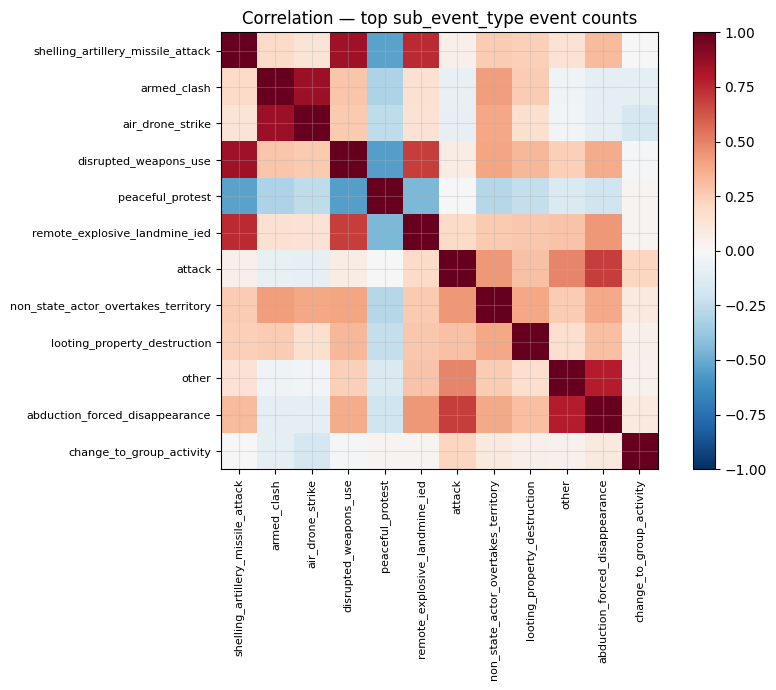

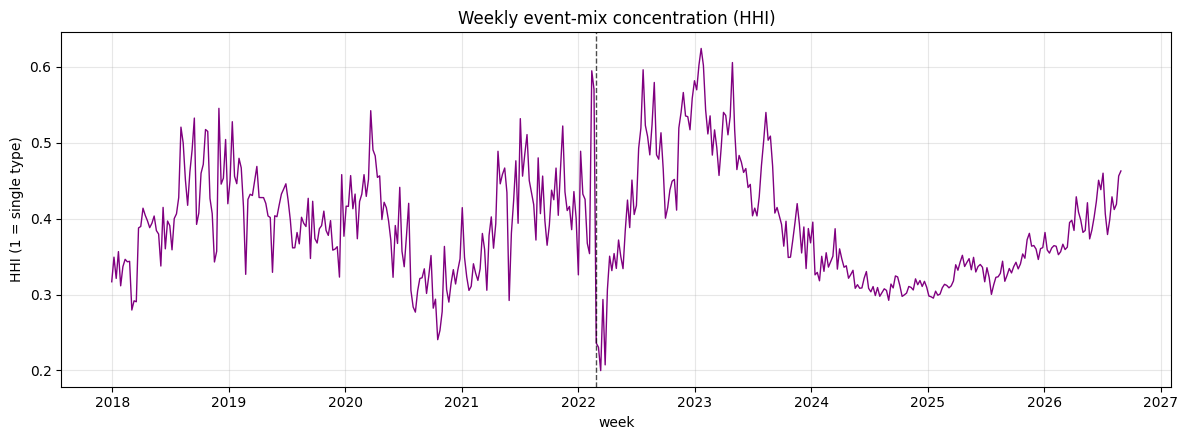

mean HHI pre=0.399, post=0.387


,total_events,total_fatalities,total_population_exposure
total_events,1.000,0.814,0.877
total_fatalities,0.814,1.000,0.759
total_population_exposure,0.877,0.759,1.000


In [8]:
print("Totals correlation:")
print(wide[["total_events", "total_fatalities", "total_population_exposure"]].corr().round(3).to_string())

event_feat = [c for c in wide.columns if c.endswith("_events") and not c.startswith("total_")]
vol = wide[event_feat].sum().sort_values(ascending=False)
keep = vol.head(12).index.tolist()
corr = wide[keep].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(keep)))
ax.set_yticks(range(len(keep)))
labels = [c.replace("_events", "") for c in keep]
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Correlation — top sub_event_type event counts")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

shares = long.pivot_table(index="week", columns="sub_event_type", values="events", aggfunc="sum", fill_value=0)
row_sum = shares.sum(axis=1).replace(0, np.nan)
p = shares.div(row_sum, axis=0)
hhi = (p ** 2).sum(axis=1)
fig, ax = plt.subplots()
ax.plot(hhi.index, hhi.values, color="purple", lw=1)
ax.axvline(pd.Timestamp("2022-02-24"), color="black", ls="--", lw=1, alpha=0.7)
ax.set_title("Weekly event-mix concentration (HHI)")
ax.set_ylabel("HHI (1 = single type)")
ax.set_xlabel("week")
fig.tight_layout()
plt.show()
print(f"mean HHI pre={hhi[hhi.index < cut].mean():.3f}, post={hhi[hhi.index >= cut].mean():.3f}")
wide[["total_events", "total_fatalities", "total_population_exposure"]].corr().round(3)


## 8. Takeaways

- ACLED Ukraine coverage here runs **2017-12-30 → 2026-08-29** (453 contiguous Saturday weeks).
- Features are country-level weekly sums of `events` / `fatalities` / `population_exposure`
  pivoted by `sub_event_type` (25 types → 75 feature columns + 3 totals).
- Activity and fatalities jump sharply after **2022-02-24**; composition shifts toward
  remote violence (shelling, air/drone strikes) and away from peaceful protest share.
- `week_start` (ISO Monday) is available for joining to the GDELT weekly panel.
- Note: summing `population_exposure` across admin1 is intentional for a country total,
  but exposures can overlap across sub-event types in the same week — treat
  cross-type exposure totals as an upper-bound intensity proxy, not unique people.

Wide panel path: `data/processed/acled_weekly_panel.parquet`  
Long panel path: `data/processed/acled_weekly_long.parquet`
